In [ ]:
import pandas as pd
import sqlite3

# Load the Kaggle CSV
df = pd.read_csv('/content/Nykaa_Product_Review.csv')
print(df.head())
print(df.columns)  # check what columns you have

# Create SQLite database
conn = sqlite3.connect('nykaa.db')
df.to_sql('products', conn, if_exists='replace', index=False)

                         Product Id Product Brand Code   Retailer  \
0  b77f3da33be6e65f6183da6ada8c07ca             BZ1000  nykaa.com   
1  f54658c5d511195b6621a640fb743b1b             BH5931  nykaa.com   
2  cdf6b3387f8976c8e38ad150173dbb6d             BH7276  nykaa.com   
3  424755c11c78b2b24ff13c675baf5d19             BZ1000  nykaa.com   
4  f7f76573099db0058ef5264c35d9d02e             BZ1000  nykaa.com   

                                Product Category    Product Brand  \
0                        Makeup > Face > Contour      ETUDE HOUSE   
1                          Brand > L'Oreal Paris    L'Oreal Paris   
2                     Makeup > Face > Foundation    The Body Shop   
3  Health & Wellness > Good for You > Super Food    True Elements   
4                      Makeup > Lips > Lip Stain  Nykaa Cosmetics   

                                        Product Name Product Price  \
0                ETUDE HOUSE Face Color Shading - 02           600   
1  L'Oreal Paris Glow Mon Amou

625

In [ ]:
# Keep only useful columns
cols_to_keep = [
    'Product Id', 'Product Brand', 'Product Category',
    'Product Name', 'Product Price', 'Product Rating',

    'Product Reviews Count', 'Retailer', 'Product Tags'
]
df = df[cols_to_keep]

# Fix data types
df['Product Price'] = pd.to_numeric(df['Product Price'], errors='coerce')
df['Product Rating'] = pd.to_numeric(df['Product Rating'], errors='coerce')
df['Product Reviews Count'] = pd.to_numeric(df['Product Reviews Count'], errors='coerce')

# Drop rows where price or rating is missing
df = df.dropna(subset=['Product Price', 'Product Rating'])

# Clean category — extract main category (before first '>')
df['Main Category'] = df['Product Category'].str.split('>').str[0].str.strip()

# Add price segment
def segment(price):
    if price < 500:
        return 'Budget'
    elif price <= 1500:
        return 'Mid-range'
    else:
        return 'Premium'

df['Price Segment'] = df['Product Price'].apply(segment)

print("Cleaned shape:", df.shape)
print("\nMain Categories found:\n", df['Main Category'].value_counts())
print("\nNull values:\n", df.isnull().sum())
df.head()

Cleaned shape: (551, 11)

Main Categories found:
 Main Category
Makeup                            164
Natural                            92
Skin                               71
Personal Care                      35
Brand                              30
Nykaa Luxe                         27
Hair                               20
Men's Store                        16
Fragrance                          11
Health & Wellness                  10
Mom & Baby                          7
NFBA 2020 Nominees Online Sale      3
Name: count, dtype: int64

Null values:
 Product Id                0
Product Brand             0
Product Category         65
Product Name              0
Product Price             0
Product Rating            0
Product Reviews Count     0
Retailer                  0
Product Tags              0
Main Category            65
Price Segment             0
dtype: int64


,Product Id,Product Brand,Product Category,Product Name,Product Price,Product Rating,Product Reviews Count,Retailer,Product Tags,Main Category,Price Segment
0,b77f3da33be6e65f6183da6ada8c07ca,ETUDE HOUSE,Makeup > Face > Contour,ETUDE HOUSE Face Color Shading - 02,600.0,4.6,4.0,nykaa.com,"ETUDE HOUSE Face Color Shading - 02, Makeup, F...",Makeup,Mid-range
1,f54658c5d511195b6621a640fb743b1b,L'Oreal Paris,Brand > L'Oreal Paris,L'Oreal Paris Glow Mon Amour Highlighting Drop...,454.0,4.3,147.0,nykaa.com,L'Oreal Paris Glow Mon Amour Highlighting Drop...,Brand,Budget
2,cdf6b3387f8976c8e38ad150173dbb6d,The Body Shop,Makeup > Face > Foundation,The Body Shop All-In-One Face Base - 045,1395.0,4.4,58.0,nykaa.com,"The Body Shop All-In-One Face Base - 045 , Mak...",Makeup,Mid-range
3,424755c11c78b2b24ff13c675baf5d19,True Elements,Health & Wellness > Good for You > Super Food,True Elements Sunflower Raw Seeds,175.0,5.0,0.0,nykaa.com,"True Elements Sunflower Raw Seeds, Wellness, S...",Health & Wellness,Budget
4,f7f76573099db0058ef5264c35d9d02e,Nykaa Cosmetics,Makeup > Lips > Lip Stain,Nykaa Wonderpuff Cushion Liquid Lipstick - Wer...,539.0,4.0,934.0,nykaa.com,NykaaÂ Wonderpuff!Â LipÂ &Â CheekÂ Cushion Lip...,Makeup,Mid-range


In [ ]:
# Save cleaned data to SQLite
conn = sqlite3.connect('nykaa.db')
df.to_sql('products', conn, if_exists='replace', index=False)
print("Saved to SQLite ✅")

Saved to SQLite ✅


In [ ]:
# Reload cleanly to avoid SettingWithCopyWarning
df = pd.read_csv('/content/Nykaa_Product_Review.csv')

cols_to_keep = [
    'Product Id', 'Product Brand', 'Product Category',
    'Product Name', 'Product Price', 'Product Rating',
    'Product Reviews Count', 'Retailer', 'Product Tags'
]
df = df[cols_to_keep].copy()  # .copy() fixes the warning

df['Product Price'] = pd.to_numeric(df['Product Price'], errors='coerce')
df['Product Rating'] = pd.to_numeric(df['Product Rating'], errors='coerce')
df['Product Reviews Count'] = pd.to_numeric(df['Product Reviews Count'], errors='coerce')
df = df.dropna(subset=['Product Price', 'Product Rating'])
df['Main Category'] = df['Product Category'].str.split('>').str[0].str.strip()

def segment(price):
    if price < 500:
        return 'Budget'
    elif price <= 1500:
        return 'Mid-range'
    else:
        return 'Premium'

df['Price Segment'] = df['Product Price'].apply(segment)

# Save to SQLite
conn = sqlite3.connect('nykaa.db')
df.to_sql('products', conn, if_exists='replace', index=False)
print("Done, no warnings! ✅")

Done, no warnings! ✅


In [ ]:
# Q1: Product count per main category
q1 = pd.read_sql_query("""
    SELECT `Main Category`, COUNT(*) as Total_Products
    FROM products
    GROUP BY `Main Category`
    ORDER BY Total_Products DESC
""", conn)
print("📊 Q1 - Products per Category")
print(q1)
# Q2: Avg price and rating per brand (top 15 by review count)
q2 = pd.read_sql_query("""
    SELECT `Product Brand`,
           ROUND(AVG(`Product Price`), 2) as Avg_Price,
           ROUND(AVG(`Product Rating`), 2) as Avg_Rating,
           SUM(`Product Reviews Count`) as Total_Reviews
    FROM products
    GROUP BY `Product Brand`
    ORDER BY Total_Reviews DESC
    LIMIT 15
""", conn)
print("\n📊 Q2 - Top 15 Brands by Reviews")
print(q2)
# Q3: Top 10 highest rated products with decent reviews
q3 = pd.read_sql_query("""
    SELECT `Product Name`, `Product Brand`, `Main Category`,
           `Product Price`, `Product Rating`, `Product Reviews Count`
    FROM products
    WHERE `Product Reviews Count` > 100
    ORDER BY `Product Rating` DESC
    LIMIT 10
""", conn)
print("\n📊 Q3 - Top 10 Rated Products")
print(q3)
# Q4: Price segment breakdown
q4 = pd.read_sql_query("""
    SELECT `Price Segment`,
           COUNT(*) as Total_Products,
           ROUND(AVG(`Product Rating`), 2) as Avg_Rating,
           ROUND(AVG(`Product Price`), 2) as Avg_Price
    FROM products
    GROUP BY `Price Segment`
    ORDER BY Avg_Price
""", conn)
print("\n📊 Q4 - Price Segment Analysis")
print(q4)
# Q5: Best performing category (rating x reviews combined)
q5 = pd.read_sql_query("""
    SELECT `Main Category`,
           ROUND(AVG(`Product Rating`), 2) as Avg_Rating,
           SUM(`Product Reviews Count`) as Total_Reviews,
           ROUND(AVG(`Product Price`), 2) as Avg_Price
    FROM products
    GROUP BY `Main Category`
    ORDER BY Total_Reviews DESC
""", conn)
print("\n📊 Q5 - Category Performance")
print(q5)

📊 Q1 - Products per Category
                     Main Category  Total_Products
0                           Makeup             164
1                          Natural              92
2                             Skin              71
3                             None              65
4                    Personal Care              35
5                            Brand              30
6                       Nykaa Luxe              27
7                             Hair              20
8                      Men's Store              16
9                        Fragrance              11
10               Health & Wellness              10
11                      Mom & Baby               7
12  NFBA 2020 Nominees Online Sale               3

📊 Q2 - Top 15 Brands by Reviews
          Product Brand  Avg_Price  Avg_Rating  Total_Reviews
0        Nykaa Naturals     282.33        4.26        32885.0
1              Biotique      89.50        4.16        30726.0
2                 Lakme     494.21    

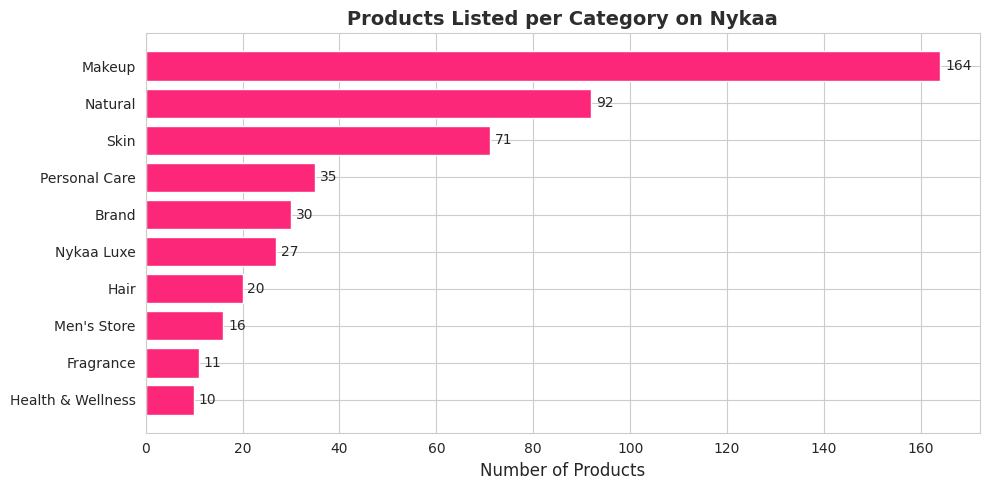

Chart 1 saved ✅


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Nykaa brand colors
PINK = '#FC2779'
LIGHT_PINK = '#FF91BB'
DARK = '#2D2D2D'

sns.set_style("whitegrid")
# 📊 Chart 1 - Products per Category (bar)
fig, ax = plt.subplots(figsize=(10, 5))
cats = df['Main Category'].value_counts().dropna().head(10)
bars = ax.barh(cats.index[::-1], cats.values[::-1], color=PINK)
ax.set_xlabel('Number of Products', fontsize=12)
ax.set_title('Products Listed per Category on Nykaa', fontsize=14, fontweight='bold', color=DARK)
for bar, val in zip(bars, cats.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('chart1_category_count.png', dpi=150)
plt.show()
print("Chart 1 saved ✅")

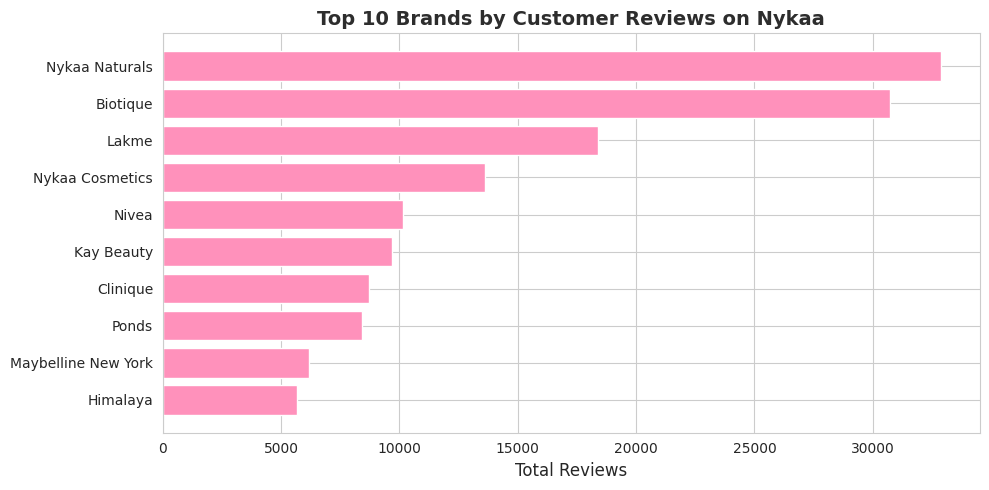

Chart 2 saved ✅


In [ ]:
# 📊 Chart 2 - Top 10 Brands by Total Reviews (bar)
fig, ax = plt.subplots(figsize=(10, 5))
top_brands = q2.head(10)
bars = ax.barh(top_brands['Product Brand'][::-1], top_brands['Total_Reviews'][::-1], color=LIGHT_PINK)
ax.set_xlabel('Total Reviews', fontsize=12)
ax.set_title('Top 10 Brands by Customer Reviews on Nykaa', fontsize=14, fontweight='bold', color=DARK)
plt.tight_layout()
plt.savefig('chart1_category_count.png', dpi=150)
plt.show()
print("Chart 2 saved ✅")

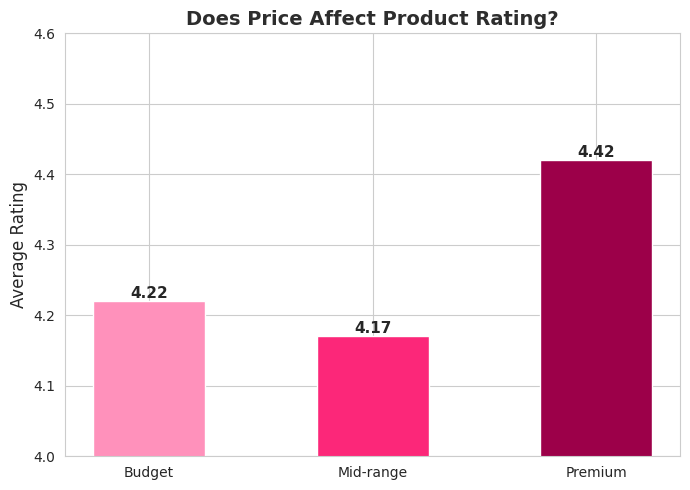

Chart 3 saved ✅


In [ ]:
# 📊 Chart 3 - Price Segment vs Avg Rating (bar)
fig, ax = plt.subplots(figsize=(7, 5))
colors = [LIGHT_PINK, PINK, '#9C0049']
bars = ax.bar(q4['Price Segment'], q4['Avg_Rating'], color=colors, edgecolor='white', width=0.5)
ax.set_ylim(4.0, 4.6)
ax.set_ylabel('Average Rating', fontsize=12)
ax.set_title('Does Price Affect Product Rating?', fontsize=14, fontweight='bold', color=DARK)
for bar, val in zip(bars, q4['Avg_Rating']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            str(val), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_category_count.png', dpi=150)
plt.show()
print("Chart 3 saved ✅")

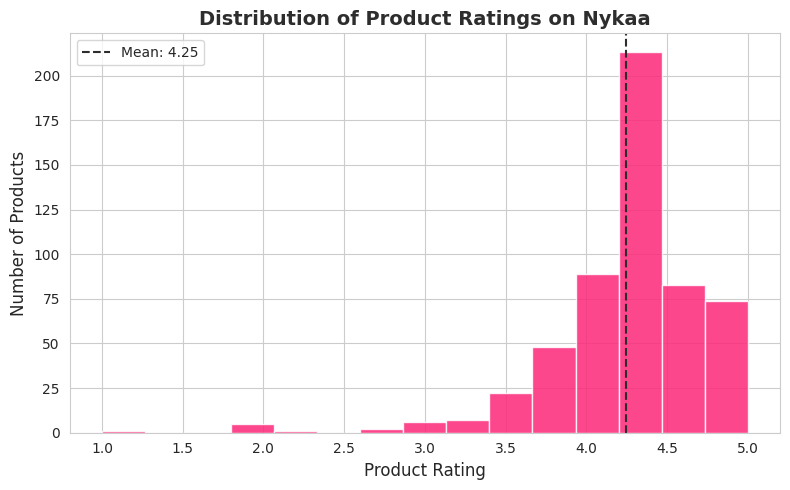

Chart 4 saved ✅


In [ ]:
# 📊 Chart 4 - Rating Distribution (histogram)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df['Product Rating'], bins=15, color=PINK, edgecolor='white', alpha=0.85)
ax.axvline(df['Product Rating'].mean(), color=DARK, linestyle='--', linewidth=1.5,
           label=f"Mean: {df['Product Rating'].mean():.2f}")
ax.set_xlabel('Product Rating', fontsize=12)
ax.set_ylabel('Number of Products', fontsize=12)
ax.set_title('Distribution of Product Ratings on Nykaa', fontsize=14, fontweight='bold', color=DARK)
ax.legend()
plt.tight_layout()
plt.savefig('chart1_category_count.png', dpi=150)
plt.show()
print("Chart 4 saved ✅")

In [ ]:
import random
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

random.seed(42)
np.random.seed(42)

n = 3000  # 3000 orders

# Sample product ids from your cleaned df
product_sample = df[['Product Id', 'Product Price', 'Main Category', 'Product Brand']].dropna()

sampled = product_sample.sample(n, replace=True).reset_index(drop=True)

orders = pd.DataFrame({
    'order_id': [f'ORD{str(i).zfill(5)}' for i in range(1, n+1)],
    'customer_id': [f'CUST{random.randint(1000, 2000)}' for _ in range(n)],
    'order_date': [datetime(2023, 1, 1) + timedelta(days=random.randint(0, 364)) for _ in range(n)],
    'product_id': sampled['Product Id'].values,
    'product_price': sampled['Product Price'].values,
    'category': sampled['Main Category'].values,
    'brand': sampled['Product Brand'].values,
    'quantity': np.random.choice([1, 2, 3], n, p=[0.75, 0.20, 0.05]),
    'discount_pct': np.random.choice([0, 10, 20, 30], n, p=[0.40, 0.30, 0.20, 0.10])
})

orders['revenue'] = (
    orders['product_price'] * orders['quantity'] * (1 - orders['discount_pct'] / 100)
).round(2)

orders['month'] = pd.to_datetime(orders['order_date']).dt.strftime('%Y-%m')
orders['month_name'] = pd.to_datetime(orders['order_date']).dt.strftime('%b %Y')

print("Orders shape:", orders.shape)
print("\nSample:")
print(orders.head())
print("\nTotal Revenue: ₹", orders['revenue'].sum().round(2))

Orders shape: (3000, 12)

Sample:
   order_id customer_id order_date  \
0  ORD00001    CUST1654 2023-08-20   
1  ORD00002    CUST1114 2023-03-30   
2  ORD00003    CUST1025 2023-08-16   
3  ORD00004    CUST1759 2023-02-14   
4  ORD00005    CUST1281 2023-12-16   

                                        product_id  product_price  \
0                 5300011d515f36df2f6588f8d24e74dd          315.0   
1                 d4277ea174bf69fd6b781c3d8e7b10e6          450.0   
2  18901030685191890103000000300000000000LCRP100IN          170.0   
3                 ad673db4c998bbb622ac079eb0c9dc2f          260.0   
4                 5862930756fbef68849d9ba594ffd3ed         5650.0   

      category            brand  quantity  discount_pct  revenue    month  \
0  Men's Store  Neemli Naturals         1            30    220.5  2023-08   
1         Hair        Herbal Me         1             0    450.0  2023-03   
2       Makeup            Lakme         1             0    170.0  2023-08   
3         Skin

In [ ]:
# Save orders to SQLite too
orders.to_sql('orders', conn, if_exists='replace', index=False)
orders.to_csv('nykaa_orders_synthetic.csv', index=False)
print("Orders saved ✅")

Orders saved ✅


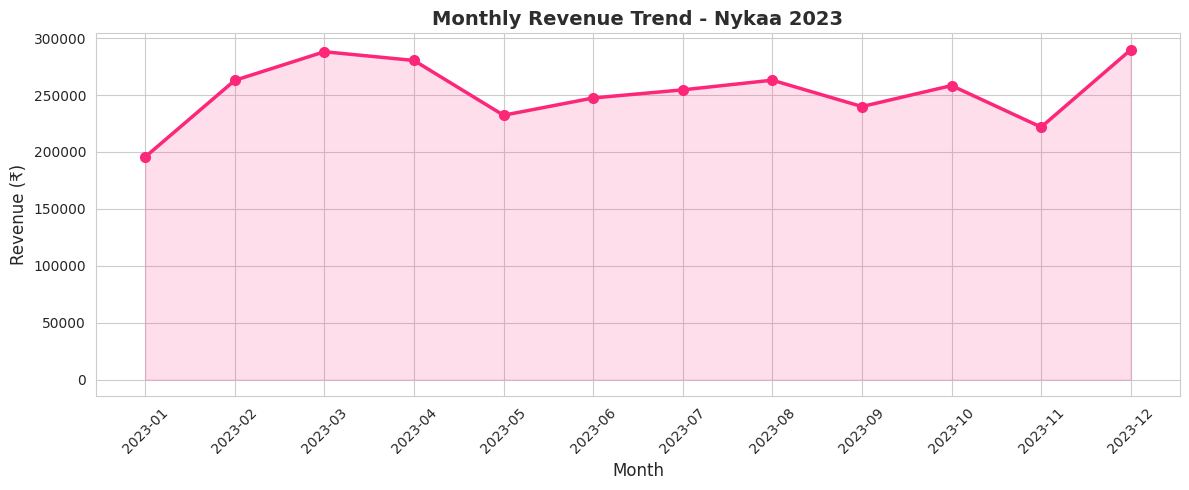

Chart 5 saved ✅


In [ ]:
# 📊 Chart 5 - Monthly Revenue Trend
monthly_rev = orders.groupby('month')['revenue'].sum().reset_index()
monthly_rev = monthly_rev.sort_values('month')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_rev['month'], monthly_rev['revenue'],
        color=PINK, marker='o', linewidth=2.5, markersize=7)
ax.fill_between(monthly_rev['month'], monthly_rev['revenue'],
                alpha=0.15, color=PINK)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Revenue (₹)', fontsize=12)
ax.set_title('Monthly Revenue Trend - Nykaa 2023', fontsize=14, fontweight='bold', color=DARK)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart5_monthly_revenue.png', dpi=150)
plt.show()
print("Chart 5 saved ✅")

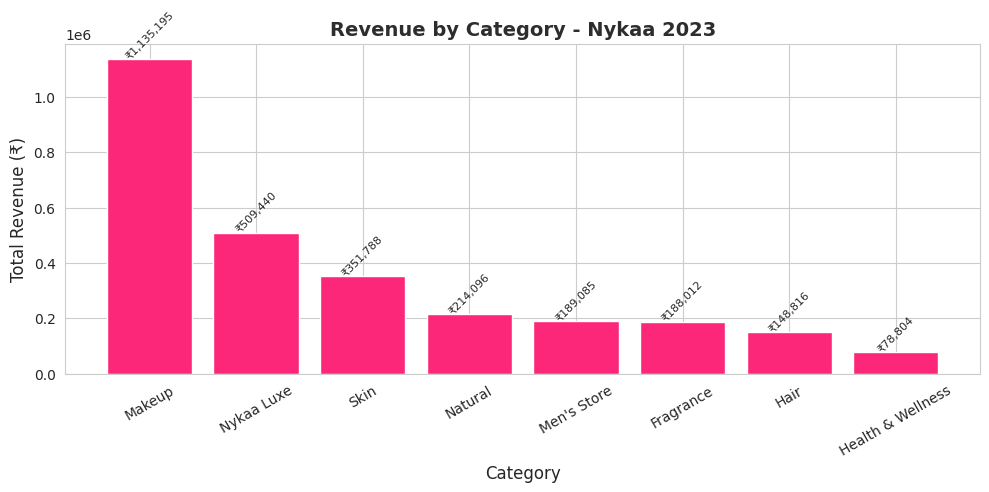

Chart 6 saved ✅


In [ ]:
# 📊 Chart 6 - Revenue by Category
cat_rev = orders.groupby('category')['revenue'].sum().sort_values(ascending=False).head(8)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(cat_rev.index, cat_rev.values, color=PINK, edgecolor='white')
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Total Revenue (₹)', fontsize=12)
ax.set_title('Revenue by Category - Nykaa 2023', fontsize=14, fontweight='bold', color=DARK)
for bar, val in zip(bars, cat_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'₹{val:,.0f}', ha='center', fontsize=8, rotation=45)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart6_revenue_by_category.png', dpi=150)
plt.show()
print("Chart 6 saved ✅")

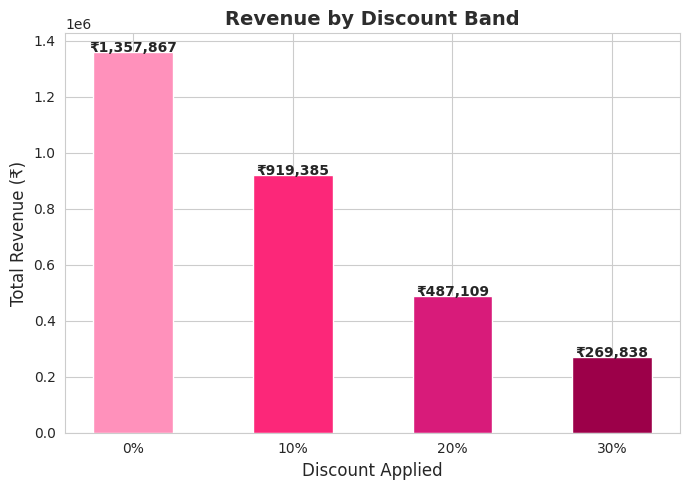

Chart 7 saved ✅


In [ ]:
# 📊 Chart 7 - Revenue by Discount Band
disc_rev = orders.groupby('discount_pct')['revenue'].sum().reset_index()
disc_rev['discount_pct'] = disc_rev['discount_pct'].astype(str) + '%'

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(disc_rev['discount_pct'], disc_rev['revenue'],
              color=[LIGHT_PINK, PINK, '#D81B7A', '#9C0049'], edgecolor='white', width=0.5)
ax.set_xlabel('Discount Applied', fontsize=12)
ax.set_ylabel('Total Revenue (₹)', fontsize=12)
ax.set_title('Revenue by Discount Band', fontsize=14, fontweight='bold', color=DARK)
for bar, val in zip(bars, disc_rev['revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'₹{val:,.0f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_discount_revenue.png', dpi=150)
plt.show()
print("Chart 7 saved ✅")

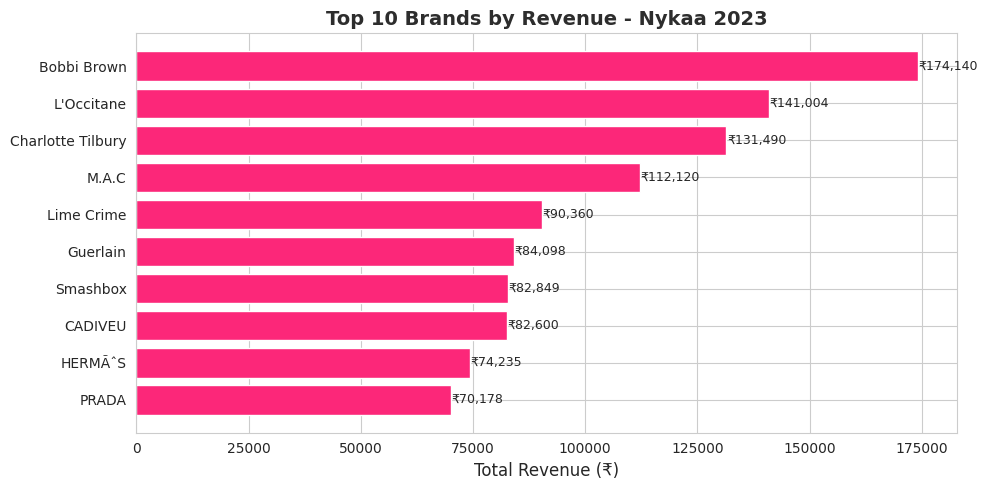

Chart 8 saved ✅


In [ ]:
# 📊 Chart 8 - Top 10 Brands by Revenue
brand_rev = orders.groupby('brand')['revenue'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(brand_rev.index[::-1], brand_rev.values[::-1], color=PINK)
ax.set_xlabel('Total Revenue (₹)', fontsize=12)
ax.set_title('Top 10 Brands by Revenue - Nykaa 2023', fontsize=14, fontweight='bold', color=DARK)
for bar, val in zip(bars, brand_rev.values[::-1]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('chart8_brand_revenue.png', dpi=150)
plt.show()
print("Chart 8 saved ✅")

In [ ]:
# Export cleaned product data
df.to_csv('nykaa_products_cleaned.csv', index=False)

# Export orders
orders.to_csv('nykaa_orders_synthetic.csv', index=False)

# Export summary tables for Power BI
q2.to_csv('brand_summary.csv', index=False)
q4.to_csv('price_segment_summary.csv', index=False)
q5.to_csv('category_summary.csv', index=False)

print("All CSVs exported ✅")
print("\nFiles ready for Power BI:")
print("1. nykaa_products_cleaned.csv")
print("2. nykaa_orders_synthetic.csv")
print("3. brand_summary.csv")
print("4. price_segment_summary.csv")
print("5. category_summary.csv")

All CSVs exported ✅

Files ready for Power BI:
1. nykaa_products_cleaned.csv
2. nykaa_orders_synthetic.csv
3. brand_summary.csv
4. price_segment_summary.csv
5. category_summary.csv
